## 🏏 IPL Performance Analysis – Problem Statement

You are provided with a small IPL dataset containing teams, players, runs, and wickets.

### Tasks

**A. Pandas Analysis**
- Total runs per team  
- Highest run scorer per team  
- Player count per team  
- Average wickets per team  
- Players with more than 50 runs  
- Players from MI or CSK  
- Players with zero wickets or more than 60 runs  
- Teams with total runs greater than 100  
- Mean and maximum runs per team  
- RCB players with less than 50 runs  

**B. Visualization Tasks**
- Runs by player (bar chart)  
- Total runs by team  
- Player vs runs line plot  
- Wickets horizontal bar chart  
- Players per team pie chart  
- Runs vs wickets scatter plot  
- Average runs by team (Seaborn)  
- Run distribution boxplot  
- Player count plot  
- Correlation heatmap  


In [4]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df= pd.DataFrame(

   {
    "Team": ["MI", "CSK", "RCB", "MI", "CSK", "RCB"],
    "Player": ["Rohit", "Dhoni", "Kohli", "Sky", "Jadeja", "Maxwell"],
    "Runs": [70, 45, 90, 55, 30, 20],
    "Wickets": [0, 1, 0, 0, 2, 1]
    
}
    
)


In [6]:
df

,Team,Player,Runs,Wickets
0,MI,Rohit,70,0
1,CSK,Dhoni,45,1
2,RCB,Kohli,90,0
3,MI,Sky,55,0
4,CSK,Jadeja,30,2
5,RCB,Maxwell,20,1


In [7]:
#A. Pandas Analysis
#1. Calculate total runs scored by each team.
df.groupby('Team')['Runs'].sum()

Team
CSK     75
MI     125
RCB    110
Name: Runs, dtype: int64

In [34]:
#2. Identify the highest run scorer from every team.
df.groupby('Team')['Runs'].max()

Team
CSK    45
MI     70
RCB    90
Name: Runs, dtype: int64

In [35]:
#3. Count how many players belong to each team.
df.groupby("Team")["Player"].count()

Team
CSK    2
MI     2
RCB    2
Name: Player, dtype: int64

In [36]:
#4. Compute the average number of wickets taken by each team.
df.groupby("Team")['Wickets'].mean()

Team
CSK    1.5
MI     0.0
RCB    0.5
Name: Wickets, dtype: float64

In [37]:
#5. Filter players who scored more than 50 runs.
df[df['Runs']>50]

,Team,Player,Runs,Wickets
0,MI,Rohit,70,0
2,RCB,Kohli,90,0
3,MI,Sky,55,0


In [12]:
#6. Display all players belonging to MI or CSK.


In [38]:
temp1=df[(df['Team']=='MI')|(df['Team']=='CSK')]
temp1[['Team','Player']]

,Team,Player
0,MI,Rohit
1,CSK,Dhoni
3,MI,Sky
4,CSK,Jadeja


In [39]:
#7. Extract players with either zero wickets or more than 60 runs.
df[(df['Wickets']==0)|(df['Runs']>60)]


,Team,Player,Runs,Wickets
0,MI,Rohit,70,0
2,RCB,Kohli,90,0
3,MI,Sky,55,0


In [22]:
#8. Show the teams whose total run count exceeds 100.
t1=df.groupby("Team")['Runs'].sum()
t1[t1>100]

Team
MI     125
RCB    110
Name: Runs, dtype: int64

In [23]:
#9. For each team, calculate mean and max runs.
df.groupby("Team")['Runs'].min()


Team
CSK    30
MI     55
RCB    20
Name: Runs, dtype: int64

In [40]:

#10. Filter RCB players who scored less than 50 runs.
df.groupby("Team")['Runs'].max()


Team
CSK    45
MI     70
RCB    90
Name: Runs, dtype: int64

<BarContainer object of 6 artists>

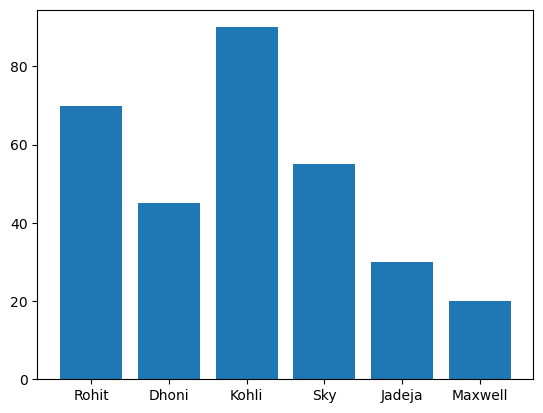

In [41]:
#B. Visualization Tasks
#1. Plot a bar chart showing runs by each player.
df.head(1)
plt.bar(df['Player'],df['Runs'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_15448\2681359418.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  x1=sns.barplot(data=df,x='Team',y='Runs', estimator=sum, ci=None)


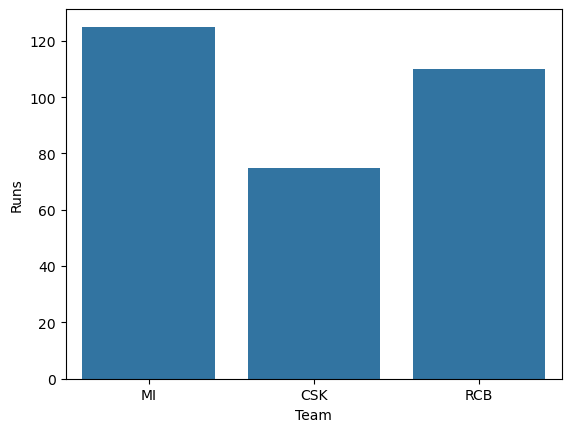

In [42]:
#2. Create a bar plot of total runs scored by each team.

x1=sns.barplot(data=df,x='Team',y='Runs', estimator=sum, ci=None)


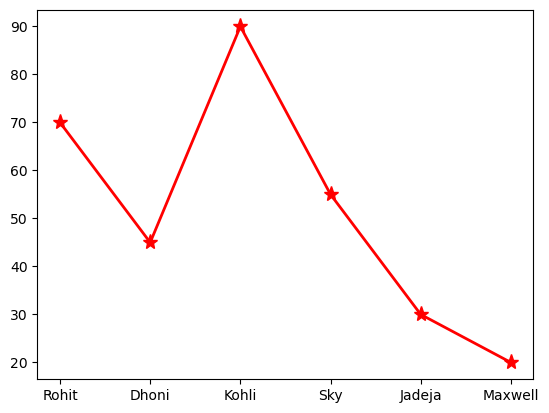

In [43]:
#3. Draw a line plot of players vs. their run scores.
plt.plot(df['Player'],df['Runs'], linestyle='-', linewidth=2,marker='*', markersize=11, color='red')

Text(0.5, 0, 'WICKETS')

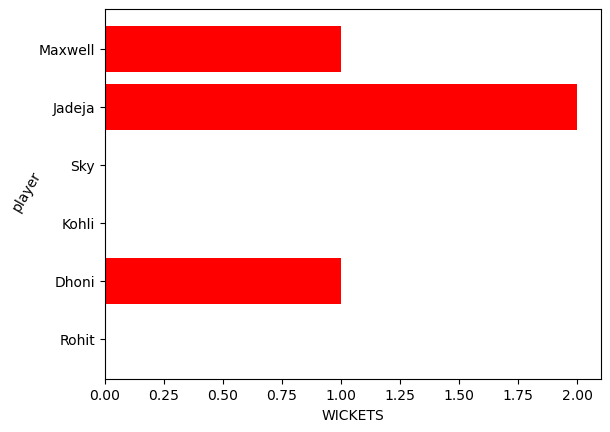

In [44]:
#4. Create a horizontal bar chart showing wickets taken by each player.
plt.barh(df['Player'],df['Wickets'],  color='red')
plt.ylabel("player", rotation=60)
plt.xlabel("WICKETS")
           

([<matplotlib.patches.Wedge at 0x1ae400e1810>,
 [Text(0.5499999722395388, 0.9526279601903919, 'MI'),
  Text(-1.0999999999999959, -9.616505800409723e-08, 'CSK'),
  Text(0.5500003659264656, -0.9526277328950455, 'RCB')],
 [Text(0.29999998485793017, 0.5196152510129409, '33%'),
  Text(-0.5999999999999978, -5.2453668002234845e-08, '33%'),
  Text(0.3000001995962539, -0.5196151270336611, '33%')])

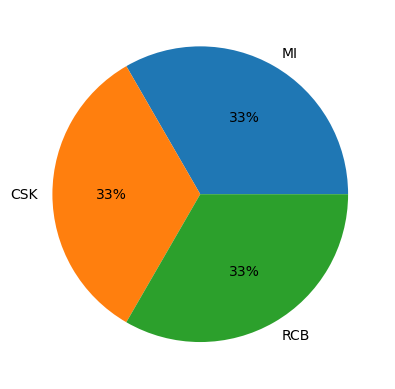

In [46]:
#5. Draw a pie chart showing the number of players per team.
temp1= df['Team'].value_counts()
plt.pie(temp1.values,labels=temp1.index, autopct='%i%%')

In [ ]:
#6. Create a scatter plot of Runs vs Wickets with team color coding.
sns.scatterplot(data=df,y='Wickets',x='Runs' , hue='Team')

In [ ]:
#7. Visualize average runs by team using a Seaborn barplot.
import numpy as np
sns.barplot(data=df, x="Team", y="Runs", estimator=np.mean)

In [ ]:
#8. Draw a boxplot showing run distribution across teams.
sns.boxplot(data=df, x="Team",y="Runs")

In [ ]:
#9. Make a countplot of the number of players per team.
sns.countplot(data=df,x="Team")


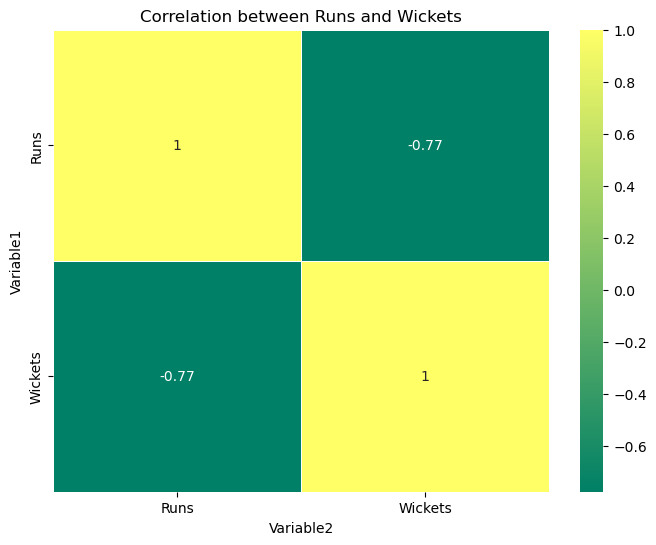

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

    # Compute correlation
temp_1 = df[['Runs','Wickets']].corr().reset_index().melt(id_vars='index')
temp_1.columns = ['Variable1','Variable2','Correlation']

# Pivot like your format
temp_2 = temp_1.pivot(index='Variable1', columns='Variable2', values='Correlation')

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(temp_2, annot=True, linewidth=0.5, cmap='summer')
plt.title("Correlation between Runs and Wickets")
plt.show()


In [ ]:
temp_1 = df[['Runs','Wickets']].corr().reset_index().melt(id_vars='index')
temp_1.columns = ['Variable1','Variable2','Correlation']

# Pivot like your format
temp_2 = temp_1.pivot(index='Variable1', columns='Variable2', values='Correlation')

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(temp_2, annot=True, linewidth=0.5, cmap='summer')


In [ ]:
plt.colormaps()

In [ ]:
temp_1 = df[['Runs','Wickets']].corr()
# heatmap paramter- extracted temp,annot ,linewidth,  cmap
# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(temp_2 ,annot=True, linewidth=0.5, cmap='rainbow_r')
